In [ ]:
"""
from openai import OpenAI

client = OpenAI(
  base_url = "https://integrate.api.nvidia.com/v1",
  api_key = "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"
)


completion = client.chat.completions.create(
  model="nvidia/nemotron-3-super-120b-a12b",
  messages=[{"role":"user","content":""}],
  temperature=1,
  top_p=0.95,
  max_tokens=16384,
  extra_body={"chat_template_kwargs":{"enable_thinking":True},"reasoning_budget":16384},
  stream=True
)

for chunk in completion:
  if not chunk.choices:
    continue
  reasoning = getattr(chunk.choices[0].delta, "reasoning_content", None)
  if reasoning:
    print(reasoning, end="")
  if chunk.choices[0].delta.content is not None:
    print(chunk.choices[0].delta.content, end="")
"""

In [ ]:
from openai import OpenAI

client = OpenAI(
  base_url = "https://integrate.api.nvidia.com/v1",
  api_key = "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"
)

completion = client.chat.completions.create(
  model="openai/gpt-oss-120b",
  messages=[{"role":"user","content":"implement a tanH function"}],
  temperature=1,
  top_p=1,
  max_tokens=4096,
  stream=False
)

reasoning = getattr(completion.choices[0].message, "reasoning_content", None)
if reasoning:
  print(reasoning)
print(completion.choices[0].message.content)

# Library Imports

In [28]:
from micrograd.engine import Value
from typing import List
import random

# Implement Forward Pass and Back-Propagation in Pytorch

Simple neuron with 2 nodes and 2 weights and a bias, and then passed through tanh() activation function. tanh() is usualy represented as the exponential. 

$ x_1 = 2, x_2 = 0, w_1 = -3, w_2 = 1, b = 6.88137 $

$ n = x_1w_1 + x_2w_2 + b  \\ $
$ f = e^{2n} \\ $
$ o = \frac{e-1}{e+1} $

1. Why the recast to double? Torch uses float32 precision and python uses double precision. Hence to make things uniform. 
2. Torch doesn't compute gradients for leaf nodes, but we do want them, hence set requires_grad == True 

In [29]:
import torch

x1 = torch.Tensor([2.0]).double()       ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()       ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()      ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()       ; w2.requires_grad = True
b = torch.Tensor([6.88137]).double()    ; b.requires_grad = True

# do forward pass
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print("Value of o: ", o.data.item())

# backpropagate
o.backward()

# print gradients of everything
print("Gradient of x1: ", x1.grad.item())
print("Gradient of w1: ", w1.grad.item())
print("Gradient of x2: ", x2.grad.item())
print("Gradient of w2: ", w2.grad.item())
print("Gradient of b: ", b.grad.item())

Value of o:  0.7071050214706146
Gradient of x1:  -1.500007465833125
Gradient of w1:  1.0000049772220834
Gradient of x2:  0.5000024886110417
Gradient of w2:  0.0
Gradient of b:  0.5000024886110417


## Let's design a Neuron

In [30]:
# Impelement a tanH function for the micrograd values data typoe
def tanhValue(inp: Value):

    inpData = torch.Tensor([inp.data]).double()
    return Value(torch.tanh(inpData).item())


In [37]:
# Takes n_inputs and gives back 1 output
class Neuron:

    def __init__(self, n_inputs):
        
        self.n_inputs = n_inputs
        self.weights = [Value(random.uniform(-1, 1)) for _ in range(n_inputs)]
        self.bias = Value(random.uniform(-1, 1))

    def __call__(self, x):


        # check if the lengths of inputs and desired length matches    
        assert(len(x) == self.n_inputs)

        # compute w*x + b: like a neuron function 
        action = sum(((w_i*x_i) for w_i, x_i in zip(self.weights, x)), self.bias)

        # pass through non-linear activation function
        outputN = tanhValue(action)

        return outputN

    def parameters(self):
        return self.weights + [self.bias]

# an array of n_outputs neurons, with each taking n_inputs inputs
class Layer:

    # define an array of neurons
    def __init__(self, n_inputs: int, n_outputs: int):
        self.neurons = [Neuron(n_inputs) for _ in range(n_outputs)]

    # pass the input through each neuron and then collate the output
    def __call__(self, x):
        outputL = [n(x) for n in self.neurons]
        return outputL[0] if len(outputL)==1 else outputL

    def parameters(self):
        Layparams = []
        for neuron in self.neurons:
            neuParams = neuron.parameters()
            Layparams.extend(neuParams)

        return Layparams

# Multiple layers now: in one layer we only told how many neurons we want in layer
## here we will give a list of sizes, and the number of layers will be inferred from the size of the list
class MLP:

    # a layer's inputs are same size as preceding layers outouts
    def __init__(self, n_inputs: int, n_outputs: List):
        sizes = [n_inputs] + n_outputs
        self.layers = [Layer(sizes[i], sizes[i+1]) for i in range(len(n_outputs))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x    

    def parameters(self):
        mlpParams = []
        for layer in self.layers:
            Layparams = layer.parameters()
            mlpParams.extend(Layparams)
        return mlpParams

In [33]:
# MLP1 = MLP(3, [4, 4, 1])
# xTrain = [[2.0, 3.0, -1.0],
#           [3.0, -1.0, 0.5],
#           [0.5, 1.0, 1.0],
#           [1.0, 1.0, -1.0]] # given inputs
# yTrain = [1.0, -1.0, -1.0, 1.0] # desired targets
# yPred = [MLP1(xt) for xt in xTrain]

# # lets compute loss now:
# loss= sum((yPr - yTr)**2 for yPr, yTr in zip(yTrain, yPred))
# loss

# Train a NN to fit a function: $x^2$

## Gradient Descent Algorithms

In [39]:
def SGD(p: micrograd.engine.Value, lr: float):

    return lr * p.grad

def momentum(v: float, p: micrograd.engine.Value, beta: float, lr: float):

    # beta is like a remembering factor, to ensure finiteness, beta must be less than 1.0
    assert beta < 1.0

    v1 = beta*v + p.grad
    return lr * v1, v1

In [42]:
# lets import some libraries
import numpy as np
import matplotlib.pyplot as plt
import micrograd.nn as nn
from micrograd.engine import Value

# lets create some training data and testing data
x_vals_train = np.random.uniform(-2, 2, 20)
x_vals_test = np.random.uniform(-2, 2, 20)

x_train = [Value(each) for each in list(x_vals_train)]
y_train = [x_tr**2 for x_tr in x_train]

# build a neural network: n_inputs: 1, n_layers: 3 [4, 4, 1]
MLP1 = nn.MLP(1, [4, 4, 1])

lr = 0.005
beta = 0.9
epochs = 3000
loss_store = np.zeros(epochs)

# define velocities of each parameter:
v = {p: 0.0 for p in MLP1.parameters()}

for epoch in range(epochs):

    # Forward pass
    y_pred = [MLP1([x]) for x in x_train]

    # MSE loss
    loss = sum((yp - yt)**2 for yp, yt in zip(y_pred, y_train)) / len(y_train)

    # Zero gradients
    for p in MLP1.parameters():
        p.grad = 0.0

    # do backward pass
    loss.backward()

    # Gradient descent
    for p in MLP1.parameters():
        # p.data -= SGD(p, lr) #lr * p.grad # Stochastic Gradient Descent
        interim, v[p] = momentum(v[p], p, beta, lr)
        p.data -= interim

    # store loss
    loss_store[epoch] = loss.data

    # print only for certain epoch numbers for better visualization
    # if epoch % 100 == 0:
    #     print(f"Epoch {epoch:4d}: Loss = {loss.data:.6f}")

# Test the trained network
y_test = [MLP1([x_ts]) for x_ts in x_vals_test]

# print predicted values
# for i in range(len(x_vals_test)):
#     print("X: ", x_vals_test[i], " Y (pred): ", y_test[i].data, " Y (true): ", x_vals_test[i]**2)

Text(0, 0.5, 'Loss Value')

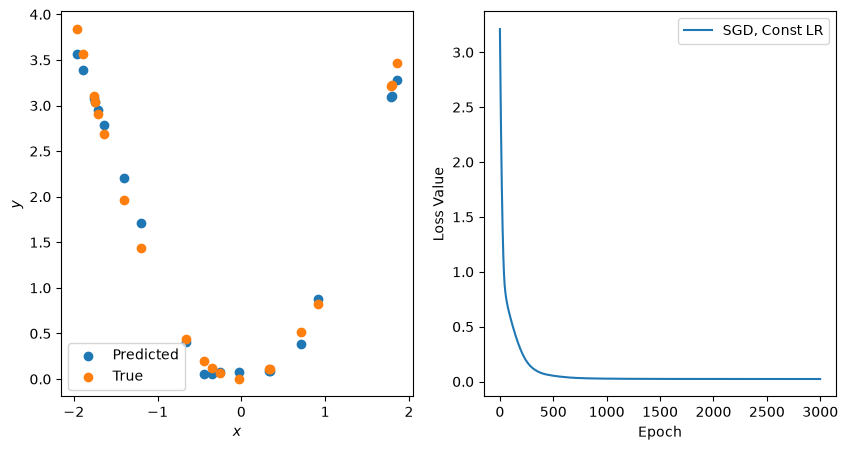

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(x_vals_test, np.array([y_test[i].data for i in range(len(y_test))]), label="Predicted")
ax[0].scatter(x_vals_test, x_vals_test**2, label="True")
ax[0].set_xlabel(r"$x$")
ax[0].set_ylabel(r"$y$")
ax[0].legend()

ax[1].plot(loss_store, label="SGD, Const LR")
ax[1].legend()
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss Value")

Text(0, 0.5, 'Loss Value')

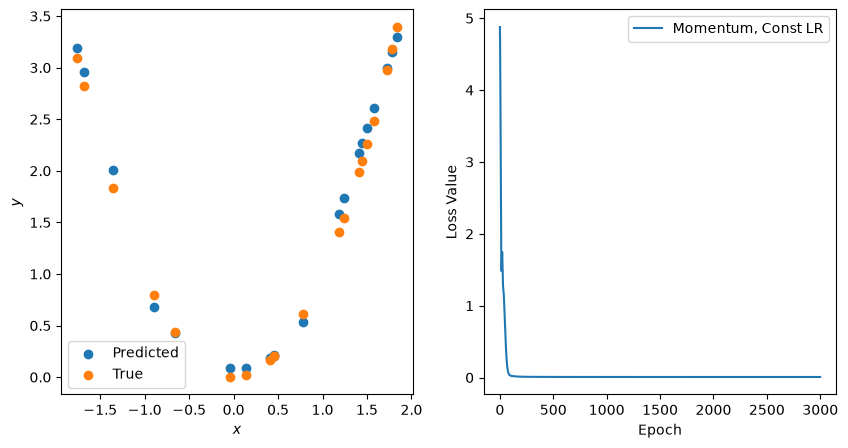

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(x_vals_test, np.array([y_test[i].data for i in range(len(y_test))]), label="Predicted")
ax[0].scatter(x_vals_test, x_vals_test**2, label="True")
ax[0].set_xlabel(r"$x$")
ax[0].set_ylabel(r"$y$")
ax[0].legend()

ax[1].plot(loss_store, label="Momentum, Const LR")
ax[1].legend()
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss Value")